# Week 3 - Exploratory Data Analysis (EDA)

## Objective

Analyze e-commerce sales data to identify patterns, trends, correlations, and key influencing factors using statistical summaries and visualizations.

## Tools Used

- Pandas
- NumPy
- Matplotlib
- Seaborn

## Project Workflow

1. Import Libraries  
2. Load Dataset  
3. Data Understanding  
4. Data Cleaning  
5. Statistical Analysis  
6. Correlation Analysis  
7. Data Visualization  
8. Trend Analysis  
9. Insights & Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Ecommerce_Sales_Data_2024_2025.csv")

In [3]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [5]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [6]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [7]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

print(df.isnull().sum())

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64


In [8]:
top_categories = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(top_categories)

Category
Home Decor     57233222.35
Furniture      56647187.90
Clothing       55053908.30
Books          54932643.00
Kitchen        54227902.30
Electronics    52587883.95
Toys           52227366.45
Sports         52069397.25
Beauty         50803409.70
Groceries      47883103.15
Name: Sales, dtype: float64


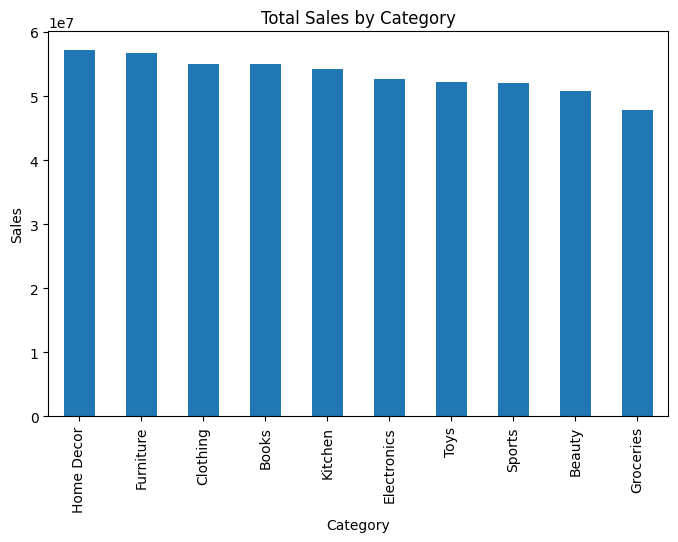

In [9]:
plt.figure(figsize=(8,5))

top_categories.plot(kind='bar')

plt.title("Total Sales by Category")

plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [10]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
East     1.358116e+08
North    1.435782e+08
South    1.232302e+08
West     1.310460e+08
Name: Sales, dtype: float64


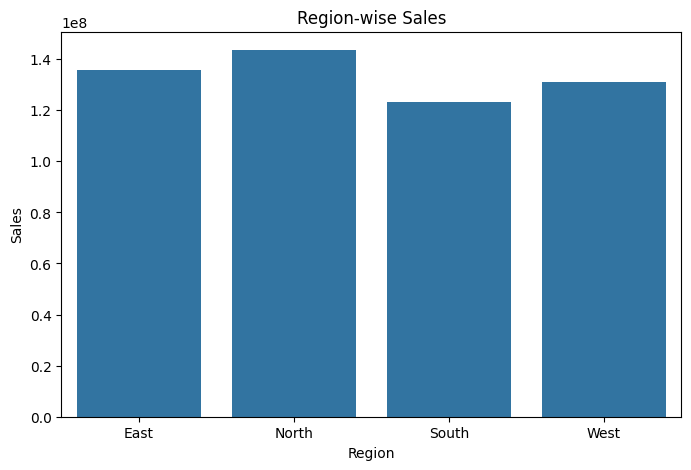

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Region-wise Sales")

plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [12]:
correlation = df[['Sales', 'Profit', 'Quantity', 'Discount']].corr()

print(correlation)

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.848792  0.588705 -0.101611
Profit    0.848792  1.000000  0.502701 -0.088516
Quantity  0.588705  0.502701  1.000000 -0.007955
Discount -0.101611 -0.088516 -0.007955  1.000000


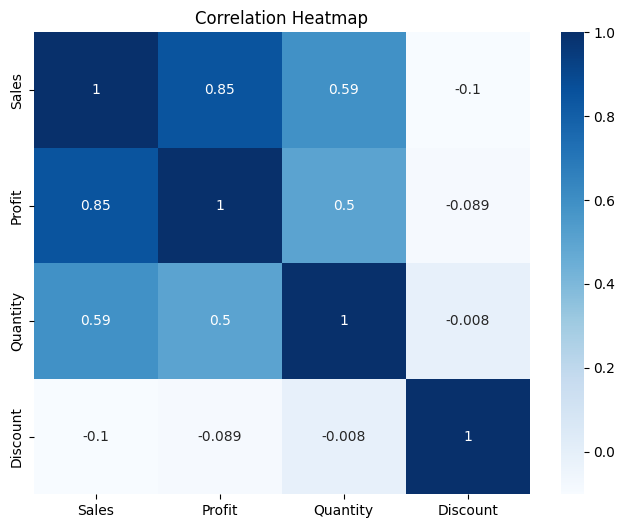

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

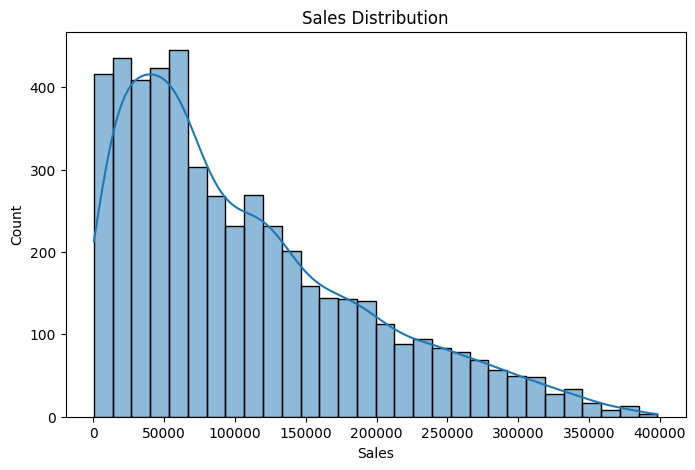

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30, kde=True)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.show()

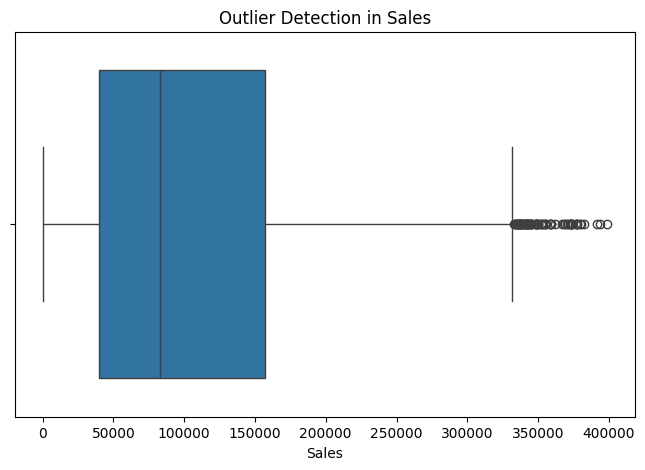

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sales'])

plt.title("Outlier Detection in Sales")

plt.show()

# Key Insights

- Electronics and Clothing categories generated the highest sales.
- Certain regions contributed significantly more revenue.
- Profit showed a positive correlation with sales.
- Discounts influenced sales performance in several categories.
- Some outliers were detected in high-value sales transactions.

# Conclusion

This project focused on exploratory data analysis of e-commerce sales data using statistical analysis and visualizations.

Key Learnings:
- Trend identification
- Correlation analysis
- Data visualization
- Insight generation
- Analytical thinking skills